In [1]:
import findspark
findspark.init()

In [2]:
from pyspark.sql import SparkSession, functions as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Initialize Spark Session
spark = SparkSession.builder\
    .appName("AnalisisPeliculas")\
    .config("spark.driver.memory", "2g")\
    .master("local[*]")\
    .getOrCreate()

In [4]:
# Lectura de datos
movies = spark.read.csv("../data/ml-latest-small/movies.csv", header=True, inferSchema=True)
ratings = spark.read.csv("../data/ml-latest-small/ratings.csv", header=True, inferSchema=True)
tags = spark.read.csv("../data/ml-latest-small/tags.csv", header=True, inferSchema=True)

In [5]:
# DEFINICION DE FUNCIONES ÚTILES

# Contar valores nulos en un DataFrame
def count_nulls(df):
    null_counts = df.select([
        F.sum(F.col(c).isNull().cast("int")).alias(c)
        for c in df.columns
    ])
    return null_counts


In [6]:
# Peliculas
movies.printSchema()
count_nulls(movies).show()
movies.show(3)

# Ratings
ratings.printSchema()
count_nulls(ratings).show()
ratings.show(3)

# Tags
tags.printSchema()
count_nulls(tags).show()
tags.show(3)

root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)

+-------+-----+------+
|movieId|title|genres|
+-------+-----+------+
|      0|    0|     0|
+-------+-----+------+

+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
+-------+--------------------+--------------------+
only showing top 3 rows
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- timestamp: integer (nullable = true)

+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     0|      0|     0|        0|
+------+-------+------+---------+

+------+-------+------+---------+
|user

## 1) Transformación de variables

In [46]:
# Timestamp conversion from Unix time to Timestamp type
ratings = ratings.withColumn("timestamp", F.from_unixtime(F.col("timestamp")).cast("timestamp"))
tags = tags.withColumn("timestamp", F.from_unixtime(F.col("timestamp")).cast("timestamp"))

# Seleccionar columnas con más del 1% de nulos
pct_null_movies = movies.select([(F.sum(F.col(c).isNull().cast("int")) / movies.count()).alias(c) for c in movies.columns])
pct_null_movies.select([c for c in pct_null_movies.columns if pct_null_movies.first()[c] > 0.01])

# En realidad ya ví que en ninguna de las 3 bases hay nulos

DataFrame[genre2: double, genre3: double]

In [8]:
# Duplicados
print(f"Movies duplicates: {movies.count() - movies.dropDuplicates().count()}")
print(f"Ratings duplicates: {ratings.count() - ratings.dropDuplicates().count()}")
print(f"Tags duplicates: {tags.count() - tags.dropDuplicates().count()}")

# NO HAY VALORES DUPLICADOS

Movies duplicates: 0
Ratings duplicates: 0
Tags duplicates: 0


In [9]:
# Dvidir la columna de géneros en múltiples columnas 
movies = movies.withColumn("genres_array", F.split(F.col("genres"), "\|")) \
               .withColumn("genre1", F.when(F.size("genres_array") >= 1, F.col("genres_array").getItem(0))) \
               .withColumn("genre2", F.when(F.size("genres_array") >= 2, F.col("genres_array").getItem(1))) \
               .withColumn("genre3", F.when(F.size("genres_array") >= 3, F.col("genres_array").getItem(2))) \
               .drop("genres_array")

# Número de generos por pelicula
movies = movies.withColumn("num_genres", F.size(F.split(F.col("genres"), "\|")))
movies.show(5)

movies.agg(F.max("num_genres").alias("max_genres")).show()
movies.select("num_genres").describe().show()

+-------+--------------------+--------------------+---------+---------+--------+----------+
|movieId|               title|              genres|   genre1|   genre2|  genre3|num_genres|
+-------+--------------------+--------------------+---------+---------+--------+----------+
|      1|    Toy Story (1995)|Adventure|Animati...|Adventure|Animation|Children|         5|
|      2|      Jumanji (1995)|Adventure|Childre...|Adventure| Children| Fantasy|         3|
|      3|Grumpier Old Men ...|      Comedy|Romance|   Comedy|  Romance|    NULL|         2|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|   Comedy|    Drama| Romance|         3|
|      5|Father of the Bri...|              Comedy|   Comedy|     NULL|    NULL|         1|
+-------+--------------------+--------------------+---------+---------+--------+----------+
only showing top 5 rows
+----------+
|max_genres|
+----------+
|        10|
+----------+

+-------+------------------+
|summary|        num_genres|
+-------+---------------

In [10]:
movies.show(10)


+-------+--------------------+--------------------+---------+---------+--------+----------+
|movieId|               title|              genres|   genre1|   genre2|  genre3|num_genres|
+-------+--------------------+--------------------+---------+---------+--------+----------+
|      1|    Toy Story (1995)|Adventure|Animati...|Adventure|Animation|Children|         5|
|      2|      Jumanji (1995)|Adventure|Childre...|Adventure| Children| Fantasy|         3|
|      3|Grumpier Old Men ...|      Comedy|Romance|   Comedy|  Romance|    NULL|         2|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|   Comedy|    Drama| Romance|         3|
|      5|Father of the Bri...|              Comedy|   Comedy|     NULL|    NULL|         1|
|      6|         Heat (1995)|Action|Crime|Thri...|   Action|    Crime|Thriller|         3|
|      7|      Sabrina (1995)|      Comedy|Romance|   Comedy|  Romance|    NULL|         2|
|      8| Tom and Huck (1995)|  Adventure|Children|Adventure| Children|    NULL|

## 2) Joins y analisis combinados

In [11]:
movies.printSchema()
ratings.show(5, truncate=False)
ratings.printSchema()

root
 |-- movieId: integer (nullable = true)
 |-- title: string (nullable = true)
 |-- genres: string (nullable = true)
 |-- genre1: string (nullable = true)
 |-- genre2: string (nullable = true)
 |-- genre3: string (nullable = true)
 |-- num_genres: integer (nullable = true)

+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|1     |1      |4.0   |964982703|
|1     |3      |4.0   |964981247|
|1     |6      |4.0   |964982224|
|1     |47     |5.0   |964983815|
|1     |50     |5.0   |964982931|
+------+-------+------+---------+
only showing top 5 rows
root
 |-- userId: integer (nullable = true)
 |-- movieId: integer (nullable = true)
 |-- rating: double (nullable = true)
 |-- timestamp: integer (nullable = true)



In [12]:
rated_movies = ratings.join(movies, on="movieId", how="inner")
rated_movies.show()
ratings.count() - rated_movies.count()  # No hay ratings sin pelicula correspondiente

+-------+------+------+---------+--------------------+--------------------+---------+---------+--------+----------+
|movieId|userId|rating|timestamp|               title|              genres|   genre1|   genre2|  genre3|num_genres|
+-------+------+------+---------+--------------------+--------------------+---------+---------+--------+----------+
|      1|     1|   4.0|964982703|    Toy Story (1995)|Adventure|Animati...|Adventure|Animation|Children|         5|
|      3|     1|   4.0|964981247|Grumpier Old Men ...|      Comedy|Romance|   Comedy|  Romance|    NULL|         2|
|      6|     1|   4.0|964982224|         Heat (1995)|Action|Crime|Thri...|   Action|    Crime|Thriller|         3|
|     47|     1|   5.0|964983815|Seven (a.k.a. Se7...|    Mystery|Thriller|  Mystery| Thriller|    NULL|         2|
|     50|     1|   5.0|964982931|Usual Suspects, T...|Crime|Mystery|Thr...|    Crime|  Mystery|Thriller|         3|
|     70|     1|   3.0|964982400|From Dusk Till Da...|Action|Comedy|Hor.

0

In [19]:
rated_movies_tagged = rated_movies.join(tags, on=["userId", "movieId", "timestamp"], how="left")
rated_movies_tagged.show(5)

count_nulls(rated_movies_tagged).show()
print(rated_movies_tagged.count())
print(movies.count())
ratings.count()  # Hay ratings sin tags correspondientes

+------+-------+---------+------+--------------------+--------------------+---------+---------+--------+----------+----+
|userId|movieId|timestamp|rating|               title|              genres|   genre1|   genre2|  genre3|num_genres| tag|
+------+-------+---------+------+--------------------+--------------------+---------+---------+--------+----------+----+
|     1|      1|964982703|   4.0|    Toy Story (1995)|Adventure|Animati...|Adventure|Animation|Children|         5|NULL|
|     1|      3|964981247|   4.0|Grumpier Old Men ...|      Comedy|Romance|   Comedy|  Romance|    NULL|         2|NULL|
|     1|      6|964982224|   4.0|         Heat (1995)|Action|Crime|Thri...|   Action|    Crime|Thriller|         3|NULL|
|     1|     47|964983815|   5.0|Seven (a.k.a. Se7...|    Mystery|Thriller|  Mystery| Thriller|    NULL|         2|NULL|
|     1|     50|964982931|   5.0|Usual Suspects, T...|Crime|Mystery|Thr...|    Crime|  Mystery|Thriller|         3|NULL|
+------+-------+---------+------

100836

In [29]:
avg_rating_movie = rated_movies_tagged\
.groupBy("movieId")\
.agg(
    F.first("title").alias("title"),
    F.round(F.avg("rating"),2).alias("avg_rating"),
    F.count("rating").alias("num_ratings")
)\
.filter(F.col("num_ratings")>=100)

avg_rating_movie.orderBy(F.col("avg_rating").desc()).show(10)
print("Películas con al menos 100 ratings:", avg_rating_movie.count())

+-------+--------------------+----------+-----------+
|movieId|               title|avg_rating|num_ratings|
+-------+--------------------+----------+-----------+
|    318|Shawshank Redempt...|      4.43|        317|
|    858|Godfather, The (1...|      4.29|        192|
|   2959|   Fight Club (1999)|      4.27|        218|
|   1221|Godfather: Part I...|      4.26|        129|
|   1213|   Goodfellas (1990)|      4.25|        126|
|  48516|Departed, The (2006)|      4.25|        107|
|     50|Usual Suspects, T...|      4.24|        204|
|    912|   Casablanca (1942)|      4.24|        100|
|  58559|Dark Knight, The ...|      4.24|        149|
|    260|Star Wars: Episod...|      4.23|        251|
+-------+--------------------+----------+-----------+
only showing top 10 rows
Películas con al menos 100 ratings: 138


In [39]:
avg_rating_user = rated_movies_tagged\
.groupBy("userId")\
.agg(
    F.count("rating").alias("num_ratings"),
    F.round(F.avg("rating"),2).alias("avg_rating"),
    F.round(F.stddev("rating"),2).alias("stddev_rating")
)

avg_rating_user.filter((F.col("avg_rating") > 4.8) & (F.col("stddev_rating") < 0.5)).show()
avg_rating_user.filter((F.col("avg_rating") <1.2) & (F.col("stddev_rating") < 0.5)).show()

+------+-----------+----------+-------------+
|userId|num_ratings|avg_rating|stddev_rating|
+------+-----------+----------+-------------+
|    53|         20|       5.0|          0.0|
|    25|         26|      4.81|         0.38|
|   515|         26|      4.85|         0.34|
+------+-----------+----------+-------------+

+------+-----------+----------+-------------+
|userId|num_ratings|avg_rating|stddev_rating|
+------+-----------+----------+-------------+
+------+-----------+----------+-------------+



## 3) EDA

(array([ 1370.,  2811.,  1791.,  7551.,  5550., 20047., 13136., 26818.,
         8551., 13211.]),
 array([0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5]),
 <BarContainer object of 10 artists>)

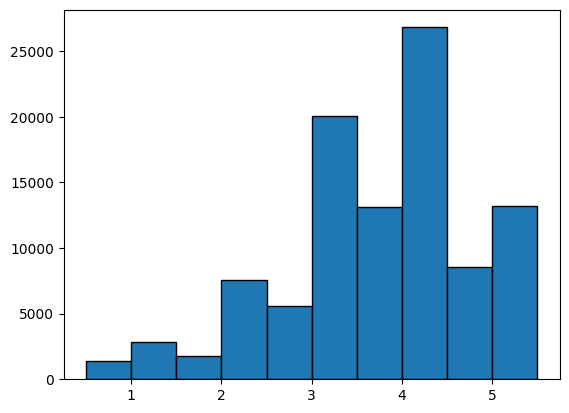

In [40]:
# histograma de ratings
ratings_pd = ratings.select("rating").toPandas()
plt.hist(ratings_pd['rating'], bins=np.arange(0.5, 5.6, 0.5), edgecolor='black')

In [43]:

# Convertimos genres a array
movies_array = movies.withColumn("genre_array", F.split(F.col("genres"), "\|"))

# Explode para tener una fila por cada género
movies_exploded = movies_array.withColumn("genre", F.explode(F.col("genre_array")))
movies_exploded.show(5)

genre_counts = movies_exploded.groupBy("genre") \
                              .count() \
                              .orderBy(F.desc("count"))
genre_counts_pd = genre_counts.toPandas()


+-------+----------------+--------------------+---------+---------+--------+----------+--------------------+---------+
|movieId|           title|              genres|   genre1|   genre2|  genre3|num_genres|         genre_array|    genre|
+-------+----------------+--------------------+---------+---------+--------+----------+--------------------+---------+
|      1|Toy Story (1995)|Adventure|Animati...|Adventure|Animation|Children|         5|[Adventure, Anima...|Adventure|
|      1|Toy Story (1995)|Adventure|Animati...|Adventure|Animation|Children|         5|[Adventure, Anima...|Animation|
|      1|Toy Story (1995)|Adventure|Animati...|Adventure|Animation|Children|         5|[Adventure, Anima...| Children|
|      1|Toy Story (1995)|Adventure|Animati...|Adventure|Animation|Children|         5|[Adventure, Anima...|   Comedy|
|      1|Toy Story (1995)|Adventure|Animati...|Adventure|Animation|Children|         5|[Adventure, Anima...|  Fantasy|
+-------+----------------+--------------------+-

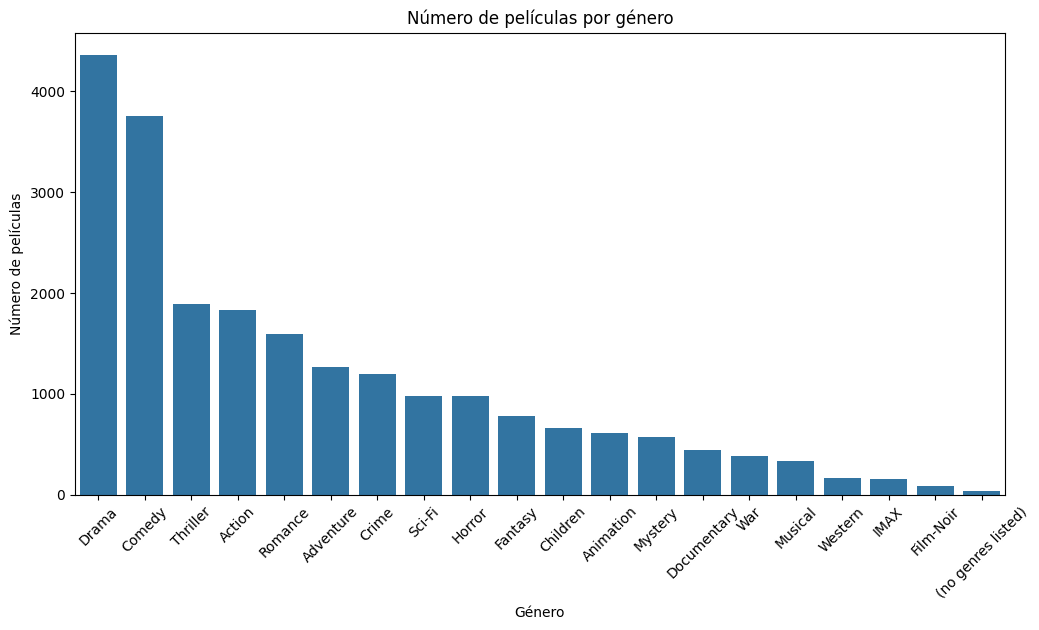

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(x="genre", y="count", data=genre_counts_pd)
plt.xticks(rotation=45)
plt.title("Número de películas por género")
plt.ylabel("Número de películas")
plt.xlabel("Género")
plt.show()


Text(0.5, 0, 'Fecha')

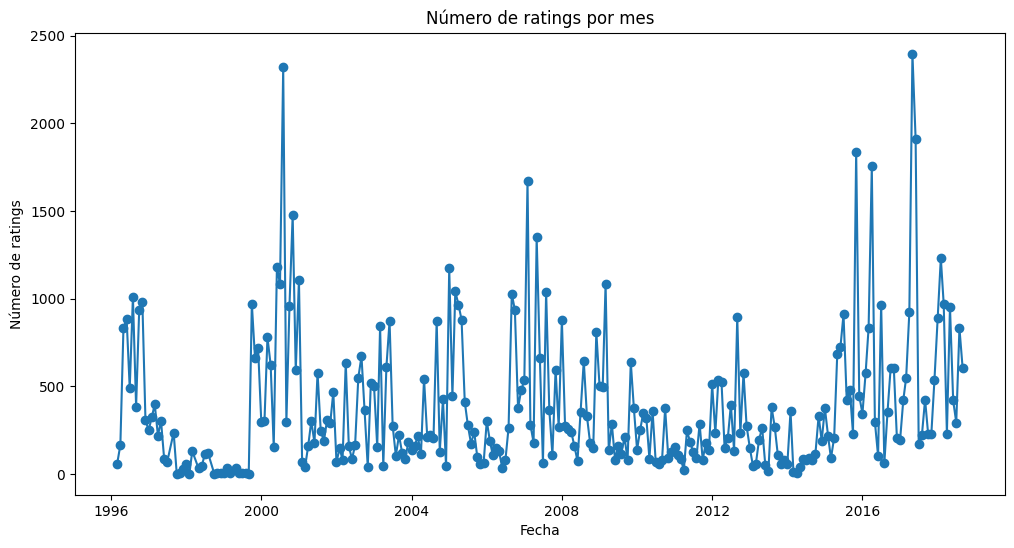

In [56]:
ratings_month = ratings.withColumn("month", F.month(F.col("timestamp")))\
        .withColumn("year", F.year(F.col("timestamp")))\
        .groupBy("year", "month")\
        .count()\
        .orderBy("year", "month")

# line plot de ratings por mes
ratings_month_pd = ratings_month.toPandas()
ratings_month_pd['date'] = pd.to_datetime(ratings_month_pd['year'].astype(str) + '-' + ratings_month_pd['month'].astype(str) + '-01')
plt.figure(figsize=(12,6))
plt.plot(ratings_month_pd['date'], ratings_month_pd['count'], marker='o')
plt.title("Número de ratings por mes")
plt.ylabel("Número de ratings")
plt.xlabel("Fecha")